In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

# Simple Usage

In [2]:
import sys
sys.path.append('../')
from CEmulator.Emulator import Xihh_CEmulator
csstemu = Xihh_CEmulator(verbose=True)

rbins = np.concatenate([np.logspace(-2, 1, 30+1)[:-1],
                                np.arange(10, 500, 5)])
rmid  = (rbins[1:] + rbins[:-1]) / 2
rind  = (rmid <= 50 ) & (rmid >= 0.1 )

Omegam = 0.3111
OmegaL = 0.6889
h      = 0.6766
sigma8 = 0.8102 
Omegab = 0.048975
ns     = 0.9665
mnu    = 0.06
Omegan = mnu/93.14/h/h
Omegac = Omegam - Omegab - Omegan
w0     = -1
wa     = 0
zlists = csstemu.zlists

# Set cosmological parameters
csstemu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)

xihh_tree = csstemu._get_xihh_tree(r=rmid, z=zlists[::-1], lgden1=-2.5, lgden2=-2.5, massdef="RockstarM200m")[::-1]
xihh_dire = csstemu.Xihh.get_xihh(r=rmid, z=zlists[::-1], lgden1=-2.5, lgden2=-2.5)[::-1]
xihh_comb = csstemu.get_xihh_lgnbar_threshold(r=rmid, z=zlists[::-1], lgden1=-2.5, lgden2=-2.5)[::-1] 

Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir_bound emulator...
Using 129 training samples.
Loading the bhmNumBin_RockstarM200m emulator...
Using 129 training samples.
Loading the hNumBin_RockstarM200m emulator...
Using 129 training samples.
The As is set to 2.106038e-09 (sigma8=0.810200) to match the input sigma8=0.810200.


In [3]:
print("xihh_tree: ", xihh_tree.shape)

xihh_tree:  (1, 1, 12, 127)


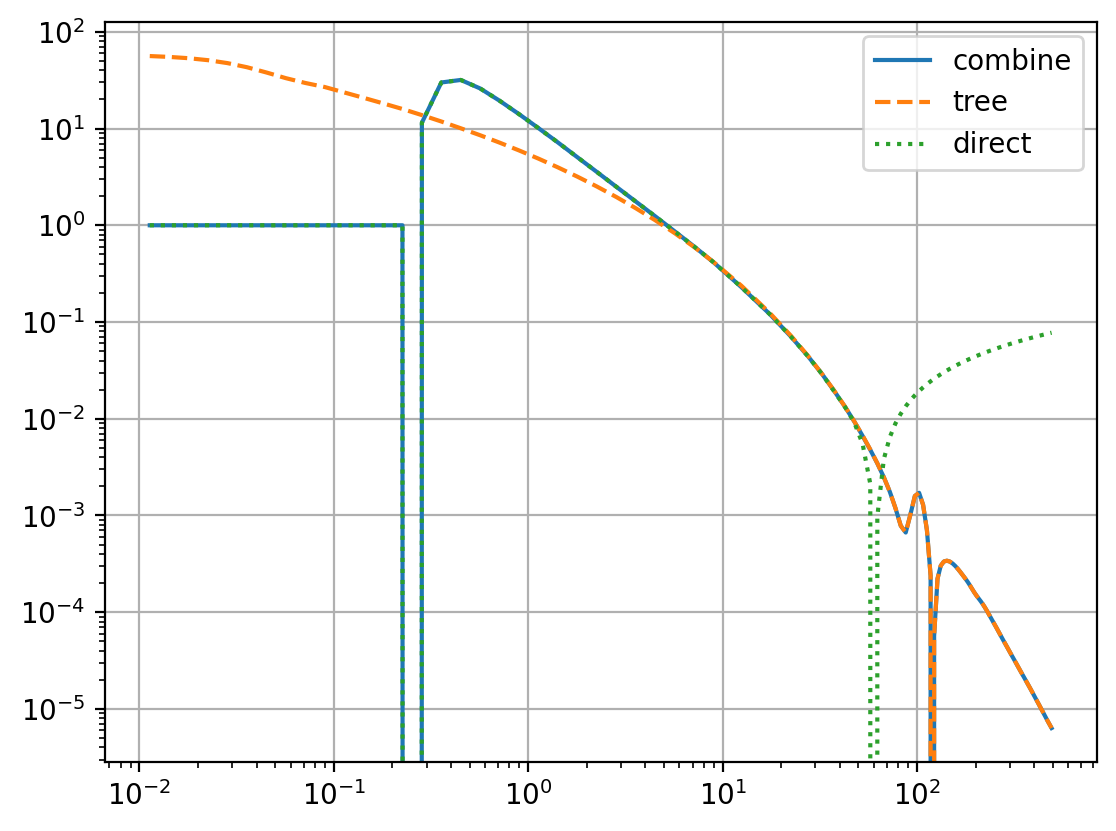

In [4]:
plt.loglog(rmid,  xihh_comb[0,0,6], label='combine', color='C0')
plt.loglog(rmid, -xihh_comb[0,0,6], color='C0')
plt.loglog(rmid,  xihh_tree[0,0,6], ls='--', label='tree', color='C1')
plt.loglog(rmid, -xihh_tree[0,0,6], ls='--', color='C1')
plt.loglog(rmid,  xihh_dire[0,0,6], ls=':', label='direct', color='C2')
plt.loglog(rmid, -xihh_dire[0,0,6], ls=':', color='C2')
plt.legend()
plt.grid(True)

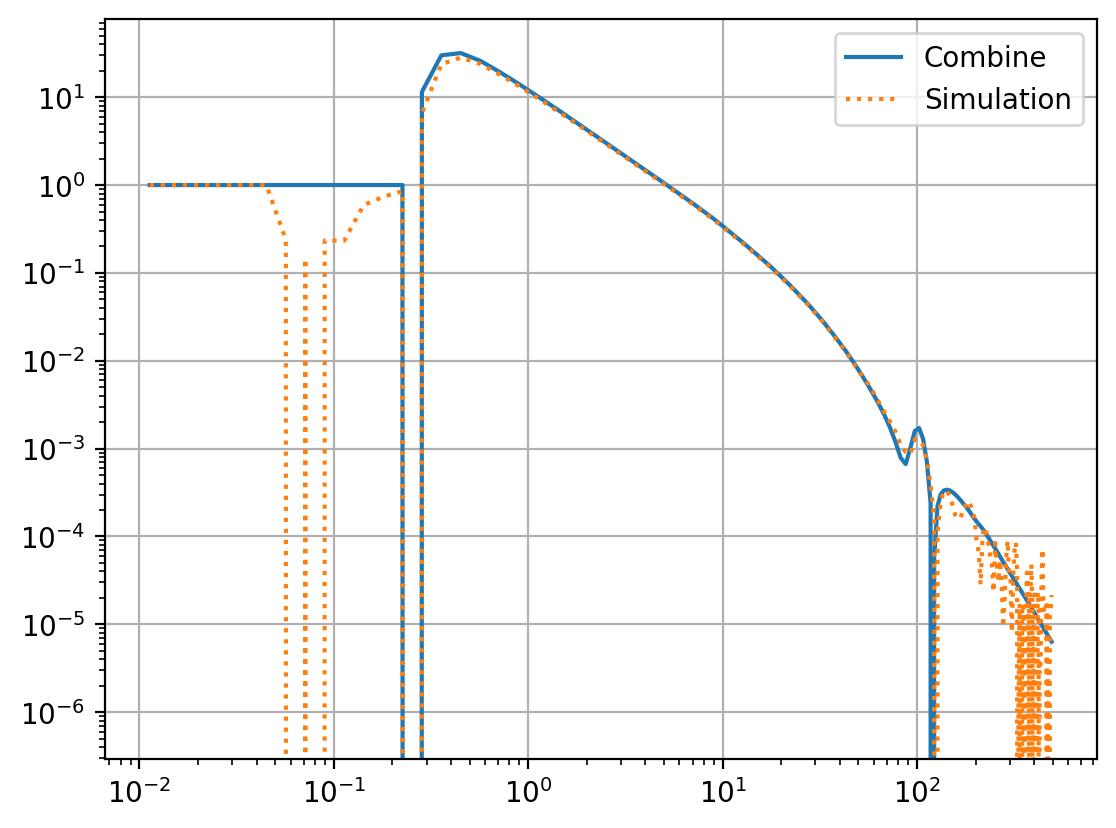

In [5]:
xihh_all = np.load("/Users/chenzhao/Desktop/mocktest/xihh_simu_n129_HybridNBin127_rockstar.npy")[0]
plt.loglog(rmid,  xihh_comb[0,0,6], label='Combine', color='C0')
plt.loglog(rmid, -xihh_comb[0,0,6], color='C0')
plt.loglog(rmid,  xihh_all [6,-1], ls=':', label='Simulation', color='C1')
plt.loglog(rmid, -xihh_all [6,-1], ls=':', color='C1')
plt.legend()
plt.grid(True)